Primera parte del código: Importar Librerías

In [1]:
import pandas as pd # Nuestra herramienta principal para manipular tablas y leer Excel.
import re # Para buscar y limpiar patrones complejos en texto (como detectar números dentro de un nombre y borrarlos).
import numpy as np # Se utiliza principalmente para realizar cálculos numéricos y manipular datos en forma de arreglos. Ayuda en el análisis de datos y el modelado estadístico.

# Visualización de Datos
import matplotlib.pyplot as plt # Crea los lienzos y la estructura base de todas nuestras gráficas matemáticas.
import seaborn as sns # Trabaja sobre matplotlib para generar gráficas estadísticas más avanzadas, estéticas y codificadas por color.

# Machine Learning y Preprocesamiento Biomédico (Scikit-Learn)
from sklearn.preprocessing import StandardScaler # Para estandarizar todas las variables (convertir a Z-scores) logrando que distintas unidades de medida pesen igual antes de calcular distancias.
from sklearn.decomposition import PCA # Principal Component Analysis. Sirve para reducir la dimensionalidad y aplastar todas las variables clínicas en un mapa 2D visible para el ojo humano.
from sklearn.mixture import GaussianMixture # Nuestro algoritmo principal de agrupamiento (Clustering). Clasifica a los pacientes en fenotipos de salud intestinal usando distribuciones de probabilidad.
from sklearn.ensemble import IsolationForest # Algoritmo de detección de anomalías. Identifica a los pacientes que rompen la norma estadística para etiquetarlos como Atípicos (Súper-Sanos, Incongruente o Disbiosis Severa).

Segunda parte del código: Cargar archivos de datos

In [2]:
# 1. Cargar los datos: Leemos el archivo Excel y guardamos toda la información en la variable 'datos_registro'
datos_registro = pd.read_excel('Microbiota_ Formulario de Equipo_Registros.xlsx')
# 2. Visualizar los datos: Mostramos las filas existentes para confirmar que se cargó bien y ver cómo lucen las columnas
datos_registro.head(113)

,ID Registro,Fecha Registro,Estatura (cm),Peso (kg),Temperatura (°C),Circunferencia Abdominal (cm),Frecuencia Cardíaca (BPM),Centro Universitario,pH Salival,Glucosa en Sangre (Mg/dL),Fitzpatrick Scale
0,1,2026-02-17 12:37:44,153.0,57,36.2,78.0,78,CUCEI,8,84 Después de desayuno,2
1,2,2026-02-17 12:37:59,173.0,80,36.3,89.0,93,CUCEI,7,109 Después de desayuno,2
2,3,2026-02-17 12:40:12,164.0,47,36.4,63.0,111,CUCEI,7,117 Después de desayuno,4
3,4,2026-02-17 12:40:20,157.0,51.5,36.2,73.0,95,CUCEI,8,88 Después de desayuno,3
4,5,2026-02-17 12:40:50,169.0,60.8,36.2,73.0,86,CUCEI,7,97 Después de desayuno,2
...,...,...,...,...,...,...,...,...,...,...,...
106,107,2025-12-04 10:41:31,172.0,89,35.9,97.5,81,CUCEI,8,84,4
107,108,2025-12-04 10:35:32,180.0,84,35.8,90.0,102,CUCEI,7,91,2
108,109,2025-12-04 10:26:07,172.0,95.5,36.0,110.0,94,CUCEI,7,100,4
109,110,2025-12-04 10:16:09,170.0,62,35.6,83.0,86,CUCEI,7,80 desayunó,3


In [3]:
# 1. Cargar los datos: Leemos el archivo Excel y guardamos toda la información en la variable 'datos_formulario'
datos_formulario = pd.read_excel('Cómo está tu microbiota.xlsx')
# 2. Visualizar los datos: Mostramos las 13 filas existentes al momneto para confirmar que se cargó bien y ver cómo lucen las columnas
datos_formulario.head(113)

,Marca temporal,Por favor anota aquí el número que se te fue asignado,1.1 Fecha de nacimiento,1.2 Sexo Biológico,1.3 ¿Naciste por cesárea? (La vía de nacimiento influye en la composición inicial del microbioma),"1.4 ¿Alguno de tus padres o abuelos nació en otro país? (La ascendencia puede influir en el microbioma debido a factores genéticos, culturales y dietéticos heredados)","1.5 En caso de haber respondido afirmativamente, por favor especifica el país o región correspondiente.",2.1 ¿Cuántos días a la semana realizas actividad física moderada o intensa (mínimo 30 minutos)?,2.2 ¿Qué tipo de actividad física realizas con mayor frecuencia? (Puedes marcar más de una),2.3 ¿Hace cuánto tiempo mantienes tu rutina actual de ejercicio?,...,6.9 ¿Con qué frecuencia te cepilla los dientes al día?,6.10 ¿Utilizas enjuague bucal?,6.11 ¿Con qué frecuencia en la última semana sentiste que no podías controlar las cosas importantes de tu vida?,"6.12 ¿Con qué frecuencia en la última semana tuviste tensión muscular, dolor de cuello o mandíbula apretada?","6.13 ¿Qué tan seguido en la última semana tuviste problemas digestivos relacionados con estrés (hinchazón, diarrea, estreñimiento)?",6.14 ¿Con qué frecuencia has tenido dificultades para relajarte?,6.15 ¿Con qué frecuencia sientes que estás bajo demasiada presión o exigencias?,7.1 ¿Tu ciclo menstrual es regular?,7.2 Duración aproximada del ciclo menstrual (días entre una menstruación y otra),7.3 Duración promedio de la menstruación (sangrado)
0,2026-02-09 13:00:35.248,49,2004-01-08 00:00:00,Hombre,Sí,No,NaN,1 a 2 días,Caminar,1 a 6 meses,...,3 veces o más,No lo utilizo,2 = Frecuentemente,1 = A veces,1 = Rara vez,2 = A menudo,2 = Frecuentemente,No aplica,No aplica,No aplica
1,2026-02-09 15:35:16.000,52,2026-02-09 00:00:00,Hombre,Sí,No,-,3 a 4 días,"Caminar, Correr",1 año o más,...,3 veces o más,"Sí, ocasionalmente",1 = A veces,2 = Frecuentemente,1 = Rara vez,2 = A menudo,1 = Algunas veces,No aplica,No aplica,No aplica
2,2026-02-17 12:28:34.123,2,2004-08-16 00:00:00,Mujer,Sí,No,NaN,1 a 2 días,"Pesas, Baile",Menos de 1 mes,...,3 veces o más,No lo utilizo,2 = Frecuentemente,2 = Frecuentemente,1 = Rara vez,1 = A veces,2 = Frecuentemente,A veces irregular,25–31 días,3 a 5 días
3,2026-02-17 12:31:29.676,1,2004-07-27 00:00:00,Mujer,Sí,No,NaN,1 a 2 días,"Natación, Pesas",1 año o más,...,3 veces o más,No lo utilizo,2 = Frecuentemente,2 = Frecuentemente,1 = Rara vez,2 = A menudo,2 = Frecuentemente,"Sí, siempre regular",25–31 días,3 a 5 días
4,2026-02-17 12:34:15.610,3,2003-12-12 00:00:00,Mujer,Sí,No,NaN,5 o más días,"Caminar, Pesas",6 a 12 meses,...,3 veces o más,"Sí, varias veces por semana",1 = A veces,0 = Nunca,1 = Rara vez,2 = A menudo,2 = Frecuentemente,A veces irregular,25–31 días,6 a 7 días
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,2025-12-04 10:54:56.339,107,2004-01-06 00:00:00,Hombre,Sí,No,NaN,3 a 4 días,"Correr, Pesas",1 a 6 meses,...,2 veces,No lo utilizo,1 = A veces,2 = Frecuentemente,0 = Nunca,1 = A veces,2 = Frecuentemente,No aplica,No aplica,No aplica
107,2025-12-04 10:16:15.013,108,2004-06-10 00:00:00,Hombre,No,No,NaN,3 a 4 días,"Caminar, Pesas",1 a 6 meses,...,3 veces o más,No lo utilizo,0 = Nunca,0 = Nunca,0 = Nunca,0 = Nunca,1 = Algunas veces,No aplica,No aplica,No aplica
108,2025-12-04 10:05:52.727,109,2003-07-25 00:00:00,Hombre,Sí,No,NaN,Nunca,Pesas,Menos de 1 mes,...,2 veces,No lo utilizo,1 = A veces,0 = Nunca,0 = Nunca,1 = A veces,1 = Algunas veces,No aplica,No aplica,No aplica
109,2025-12-04 09:58:41.836,110,2002-07-13 00:00:00,Hombre,Sí,No,NaN,1 a 2 días,"Caminar, Correr",6 a 12 meses,...,2 veces,"Sí, ocasionalmente",3 = Muy frecuentemente,2 = Frecuentemente,0 = Nunca,1 = A veces,1 = Algunas veces,No aplica,No aplica,No aplica


Tercera Parte: unir registros

In [4]:
# Definimos los nombres exactos de las columnas en los archivos Excel
columna_id_form = 'Por favor anota aquí el número que se te fue asignado' # En Formulario
columna_id_reg = 'ID Registro' # En Registros

# Función para estandarizar los números a formato de 3 dígitos (ej. "1" -> "001", "1.0" -> "001")
def formatear_id(valor):
    if pd.isna(valor): # Si la celda está vacía, no hace nada
        return ""
    
    # 1. Convertimos el valor a texto (string).
    # 2. Si Pandas lo leyó como decimal (ej. "1.0"), le quitamos el ".0".
    # 3. Quitamos espacios en blanco accidentales (strip).
    texto_id = str(valor).replace('.0', '').strip()
    
    # 4. zfill(3) asegura que siempre tenga 3 caracteres, rellenando con ceros a la izquierda
    return texto_id.zfill(3)

# Creamos la columna 'id_match' en ambos archivos aplicando nuestro formato seguro
datos_formulario['id_match'] = datos_formulario[columna_id_form].apply(formatear_id)
datos_registro['id_match'] = datos_registro[columna_id_reg].apply(formatear_id)

# Unimos las dos tablas usando la columna estandarizada 'id_match'
# how='inner' se queda SOLO con los pacientes que tienen el mismo número en ambos archivos
df_final = pd.merge(datos_formulario, datos_registro, on='id_match', how='inner')
df_final.index = range(1, len(df_final) + 1) # Obligamos al índice a empezar en 1 en lugar de 0

# DIAGNÓSTICO DE UNIÓN
print("--- REPORTE DE UNIÓN DE ARCHIVOS ---")
print(f"Total de filas en Formulario: {len(datos_formulario)}")
print(f"Total de filas en Registros:  {len(datos_registro)}")
print(f"Total de UNIONES EXITOSAS: {len(df_final)}\n")

# Resultados de Prueba:
# Mostramos una muestra para verificar visualmente que el 'id_match' empató bien
columnas_verificacion = ['id_match', columna_id_form, columna_id_reg]
print("--- MUESTRA DE DATOS UNIDOS ---")
print(df_final[columnas_verificacion].head())

--- REPORTE DE UNIÓN DE ARCHIVOS ---
Total de filas en Formulario: 111
Total de filas en Registros:  111
Total de UNIONES EXITOSAS: 111

--- MUESTRA DE DATOS UNIDOS ---
  id_match  Por favor anota aquí el número que se te fue asignado  ID Registro
1      049                                                 49               49
2      052                                                 52               52
3      002                                                  2                2
4      001                                                  1                1
5      003                                                  3                3


Cuarta Parte: preparación y limpieza de variables clínicas y antopométricas 

In [5]:
# Limpieza de columnas numéricas
# Definimos las columnas que DEBEN ser números
cols_numericas = ['Peso (kg)', 'Estatura (cm)', 'Temperatura (°C)', 'Circunferencia Abdominal (cm)', 'Frecuencia Cardíaca (BPM)', 'pH Salival', 'Glucosa en Sangre (Mg/dL)', 'Fitzpatrick Scale', '4.1 ¿Cuál de las siguientes imágenes representa mejor el tipo de heces que tienes la mayoría de los días?', '6.9  ¿Con qué frecuencia te cepilla los dientes al día?  '] 

# Función para extraer solo números
def limpiar_numeros(valor):
    # Si la celda contiene texto (string), como por ejemplo 165cm o 70kg:
    if isinstance(valor, str):
        # Usamos una expresión regular (re) que funciona como un escáner.
        # Busca y extrae cualquier cosa que tenga forma de número (entero o decimal).
        numeros = re.findall(r"[-+]?\d*\.\d+|\d+", valor)
        # Si encontró un número, lo convierte a formato matemático puro (float). 
        # Si no encontró nada devuelve un valor nulo (NaN).
        return float(numeros[0]) if numeros else np.nan
    # Si el valor de la celda ya era un número desde el principio, lo deja igual.
    return valor

# Aplicamos la limpieza
for col in cols_numericas:
    if col in df_final.columns:
        df_final[col] = df_final[col].apply(limpiar_numeros)
        
        if col in ['Peso (kg)', 'Estatura (cm)', 'Circunferencia Abdominal (cm)']:
            # Para datos antropométricos (que son continuos y suelen tener una distribución normal), rellenamos los vacíos usando el promedio de toda la población estudiada.
            df_final[col] = df_final[col].fillna(df_final[col].mean())
        else:
            # Para datos biológicos discretos o escalas, el promedio no tiene sentido médico. 
            # Aquí usamos la mediana, que es mucho más resistente a valores atípicos.
            df_final[col] = df_final[col].fillna(df_final[col].median())
            
        print(f"Columna '{col}' limpiada e imputada correctamente.")
    else:
        print(f"No se encontró la columna '{col}'.")

# Visualización final
cols_identidad = ['id_match'] 
cols_mostrables = [c for c in cols_numericas if c in df_final.columns]

print("\n--- TABLA RESULTANTE (Identidad + Datos Limpios) ---")
print(df_final[cols_identidad + cols_mostrables].head(113))

Columna 'Peso (kg)' limpiada e imputada correctamente.
Columna 'Estatura (cm)' limpiada e imputada correctamente.
Columna 'Temperatura (°C)' limpiada e imputada correctamente.
Columna 'Circunferencia Abdominal (cm)' limpiada e imputada correctamente.
Columna 'Frecuencia Cardíaca (BPM)' limpiada e imputada correctamente.
Columna 'pH Salival' limpiada e imputada correctamente.
Columna 'Glucosa en Sangre (Mg/dL)' limpiada e imputada correctamente.
Columna 'Fitzpatrick Scale' limpiada e imputada correctamente.
Columna '4.1 ¿Cuál de las siguientes imágenes representa mejor el tipo de heces que tienes la mayoría de los días?' limpiada e imputada correctamente.
Columna '6.9  ¿Con qué frecuencia te cepilla los dientes al día?  ' limpiada e imputada correctamente.

--- TABLA RESULTANTE (Identidad + Datos Limpios) ---
    id_match  Peso (kg)  Estatura (cm)  Temperatura (°C)  \
1        049       73.0          178.0              36.0   
2        052       72.0          175.0              36.4   


Quinta Parte: preguntas categóricas a valores numéricos

In [6]:
# Creación de diccionarios de mapeo: Estos diccionarios funcionan como traductores.
# Clave (izquierda): Lo que buscamos en el Excel (ej. 'si', 'sí', 'no lo hago').
# Valor (derecha): El número en el que se convertirá.
mapa_si_no = { 
    # Normalizamos variantes: con acento y sin acento valen 1
    'sí': 1, 'si': 1, 'no': 0, 
    # Variantes negativas específicas de tus preguntas se convierten en 0
    'no lo hago': 0, 'no lo utilizo': 0, 'no consumo': 0, 'no aplica': 0 
}

mapa_frecuencia_dias = { 
    'nunca': 0, 
    # Agrupamos variantes de escritura para evitar errores si falta un acento
    '1 a 2 días': 1, '1 a 2 dias': 1,
    '3 a 4 días': 2, '3 a 4 dias': 2,
    '5 o más días': 3, '5 o mas dias': 3, '5 o más dias': 3
}

mapa_antiguedad = { 
    'menos de 1 mes': 0, '1 a 6 meses': 1, '6 a 12 meses': 2, '1 año o más': 3, '1 año o mas': 3
}

mapa_horas_sedentarias = { 
    'menos de 4 horas': 0, '4 a 6 horas': 1, '7 a 9 horas': 2, 'más de 9 horas': 3, 'mas de 9 horas': 3
}

mapa_ayuno = { 
    'menos de 8 horas': 0, '8 a 10 horas': 1, '10 a 12 horas': 2, 'más de 12 horas': 3
}

mapa_tiempo_comidas = { 
    'menos de 2 horas': 0, '2 a 4 horas': 1, '4 a 6 horas': 2, 'más de 6 horas': 3
}

mapa_porciones = { 
    '0': 0, '1 a 2': 1, '3 a 4': 2, '5 o más': 3, '5 o mas': 3
}

mapa_fermentados = { 
    'nunca': 0, 'rara vez (1 vez al mes o menos)': 1, 
    'ocasionalmente (2 a 4 veces al mes)': 2, 'frecuentemente (1 o más veces por semana)': 3
}

mapa_fibra = { 
    'nunca': 0, '1 a 2 veces por semana': 1, '3 a 5 veces por semana': 2, 'diario': 3 
}

mapa_dieta = { 
    'omnívora (consume de todo)': 0, 'omnivora (consume de todo)': 0,
    'vegetariana': 1, 'vegana': 2, 'pescetariana': 3, 
    'cetogénica / baja en carbohidratos': 4, 'mediterránea': 5
}

mapa_uso_frec = { 
    'no consumo': 0, 'no lo utilizo': 0, 
    'sí, ocasionalmente': 1, 'si, ocasionalmente': 1,
    'sí, varias veces por semana': 2, 'si, varias veces por semana': 2,
    'sí, diariamente': 3, 'si, diariamente': 3
}

mapa_evacuacion = { 
    'menos de 3 veces por semana': 0, '3 veces por semana a una vez al día': 1, 
    '2 a 3 veces al día': 2, 'más de 3 veces al día': 3 
}

mapa_enfermedad_anual = { 
    '1 vez': 1, '2  a 3 veces': 2, '2 a 3 veces': 2, '4 o más veces': 3 
}

mapa_sueno_horas = { 
    '5 o menos': 0, '5 a 6 horas': 1, '7 a 8 horas': 2, 'más de 8 horas': 3 
}

mapa_estres = { 
    'bajo': 1, 'moderado': 2, 'alto': 3, 'muy alto': 4 
}

mapa_habitos_nocivos = { 
    'nunca': 0, 'ocasionalmente (menos de 1 vez al mes)': 1, 
    'mensualmente (1 a 3 veces al mes)': 2, 'semanalmente (1–3 veces por semana)': 3, 
    'frecuentemente (4 o más veces por semana)': 4 
}

mapa_calidad_sueno = { 
    'muy mala': 1, 'mala': 2, 'adecuada': 3, 'buena': 4, 'excelente': 5 
}

mapa_psico = { 
    '0 = nunca': 0, 
    '1 = a veces': 1, '1 = rara vez': 1, '1 = algunas veces': 1, 
    '2 = frecuentemente': 2, '2 = varias veces': 2, '2 = a menudo': 2, 
    '3 = muy frecuentemente': 3, '3 = casi todos los días': 3, '3 = muy a menudo': 3, '3 = todos los días': 3 
}

mapa_ciclo_reg = { 
    'no aplica': 0, 'muy irregular / no tengo ciclo': 1, 
    'a veces irregular': 2, 'sí, siempre regular': 3 
}

mapa_ciclo_dur = { 
    'no aplica': 0, 'menos de 24 días': 1, '25–31 días': 2, 'más de 32 días': 3 
}

mapa_sangrado = { 
    'no aplica': 0, '1 a 2 días': 1, '3 a 5 días': 2, '6 a 7 días': 3, 'más de 7 días': 4 
}

# Lista de configuración: Esta lista contiene tuplas: (Identificador de Columna, Mapa a usar). Usamos solo el número para buscar la columna
configuracion = [
    # Sección 1 y 2: Datos Generales || Actividad Física
    ('1.3', mapa_si_no),
    ('1.4', mapa_si_no),
    ('2.1', mapa_frecuencia_dias),
    ('2.3', mapa_antiguedad),
    ('2.4', mapa_horas_sedentarias),
    # Sección 3: Alimentación
    ('3.1', mapa_ayuno),
    ('3.3', mapa_tiempo_comidas),
    ('3.4', mapa_porciones),
    ('3.5', mapa_frecuencia_dias),
    ('3.6', mapa_fermentados),
    ('3.8', mapa_fibra),
    ('3.9', mapa_dieta),
    ('3.10', mapa_si_no), 
    ('3.12', mapa_uso_frec),
    # Sección 4 y 5: Escala de Heces de Bristol || Uso de Medicamentos y Salud Digestiva
    ('4.2', mapa_evacuacion),
    ('5.1', mapa_enfermedad_anual),
    ('5.3', mapa_si_no),
    ('5.4', mapa_si_no),
    ('5.7', mapa_si_no),
    # Sección 6 y 7: Hábitos y Estilo de Vida || Salud Menstrual
    ('6.1', mapa_sueno_horas),
    ('6.2', mapa_estres), 
    ('6.3', mapa_si_no), 
    ('6.4', mapa_habitos_nocivos),
    ('6.5', mapa_si_no),
    ('6.6', mapa_habitos_nocivos),
    ('6.7', mapa_calidad_sueno),
    ('6.8', mapa_si_no),
    ('6.10', mapa_uso_frec),
    ('6.11', mapa_psico),
    ('6.12', mapa_psico),
    ('6.13', mapa_psico),
    ('6.14', mapa_psico),
    ('6.15', mapa_psico),
    ('7.1', mapa_ciclo_reg),
    ('7.2', mapa_ciclo_dur),
    ('7.3', mapa_sangrado)
]

# Procesamiento automático
cols_listas = [] # Lista vacía para guardar los nombres de las columnas

print("\n--- INICIANDO MAPEADO DE PREGUNTAS CATEGÓRICAS ---")

for id_col, mapa in configuracion:
    coincidencias = [col for col in df_final.columns if str(col).strip().startswith(id_col)]
    
    if coincidencias:
        col_real = coincidencias[0] 
        # Convertimos a string, pasamos a minúsculas y quitamos espacios
        df_final[col_real] = df_final[col_real].astype(str).str.lower().str.strip()
        
        # Mapeamos. Los valores no encontrados en el diccionario se volverán NaN
        df_final[col_real] = df_final[col_real].map(mapa)
        
        # Renombramos a la versión corta
        df_final.rename(columns={col_real: id_col}, inplace=True)
        cols_listas.append(id_col)
    else:
        pass

# Caso Especial 3.2 (Comidas al día)
# En los formularios, la gente suele elegir opciones como "4 o más". Matemáticamente, no podemos multiplicar o sumar la letra "o" ni la palabra "más".
# Por lo tanto, necesitamos convertir ese límite superior en un número puro.
cols_32 = [c for c in df_final.columns if str(c).strip().startswith('3.2')] # Buscamos la columna exacta sin importar qué tan larga sea la pregunta de texto.
if cols_32:
    col_real = cols_32[0]
    # Reemplazo de texto: Buscamos variaciones (con y sin acento) y las convertimos en "4".
    df_final[col_real] = df_final[col_real].astype(str).replace({'4 o más': '4', '4 o mas': '4'})
    # Forzamos la columna a ser numérica. El parámetro errors='coerce' es nuestra red de seguridad: si encuentra texto basura que no pudo convertir, lo transforma en un NaN seguro en lugar de detener y crashear todo el programa.
    df_final[col_real] = pd.to_numeric(df_final[col_real], errors='coerce') 
    # Renombramos la columna para que quede corta y limpia
    df_final.rename(columns={col_real: '3.2'}, inplace=True)
    cols_listas.append('3.2')

# Caso Especial Preguntas de Selección Múltiple (2.2 Actividad y 5.6 Síntomas)
# Problema Clínico: Un paciente puede responder "Estreñimiento, Inflamación, Acidez".
# Un modelo de Machine Learning NO puede leer listas separadas por comas en una sola celda.
# Solución (One-Hot Encoding): Crear una columna nueva para cada síntoma con valor 1 o 0 (Sí/No).

# Definimos nuestras preguntas múltiples y el prefijo para no confundir columnas nuevas.
cols_multiples_config = [('2.2', 'Act_'), ('5.6', 'Sint_')]
cols_generadas = [] # Aquí guardaremos los nombres de todas las nuevas columnas

for id_col, prefijo in cols_multiples_config:
    # Encontramos el nombre completo de la pregunta en la tabla
    coincidencias = [col for col in df_final.columns if str(col).strip().startswith(id_col)]
    if coincidencias:
        col_real = coincidencias[0]
        # Creamos las variables dummy
        dummies = df_final[col_real].str.get_dummies(sep=', ').add_prefix(prefijo)
        cols_generadas.extend(dummies.columns.tolist())
        df_final = pd.concat([df_final, dummies], axis=1)

# Visualización final
print("Columnas categóricas mapeadas a valores numéricos.")

# Ordenamos numéricamente
# Esto usa una función lambda que extrae los dígitos para ordenarlos con lógica humana
cols_listas.sort(key=lambda s: [int(u) for u in s.split('.') if u.isdigit()])

# Juntamos el ID del paciente, las preguntas normales, y nuestras nuevas columnas
columnas_finales = ['id_match'] + cols_listas + cols_generadas
cols_a_imprimir = [c for c in columnas_finales if c in df_final.columns]

pd.set_option('display.max_columns', None) # Mostrar todas las columnas
pd.set_option('display.width', 1000) # Hacer la consola más ancha
pd.set_option('display.max_rows', 20) # Mostrar máximo 20 filas para no saturar la pantalla

print("\n--- TABLA RESULTANTE (Categóricas Mapeadas) ---")
print(df_final[cols_a_imprimir].head(113))


--- INICIANDO MAPEADO DE PREGUNTAS CATEGÓRICAS ---
Columnas categóricas mapeadas a valores numéricos.

--- TABLA RESULTANTE (Categóricas Mapeadas) ---
    id_match  1.3  1.4  2.1  2.3  2.4  3.1  3.2  3.3  3.4  3.5  3.6  3.8  3.9  3.10  3.12  4.2  5.1  5.3  5.4  5.7  6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.10  6.11  6.12  6.13  6.14  6.15  7.1  7.2  7.3  Act_Baile  Act_Basquetbol   Act_Caminar  Act_Ciclismo  Act_Correr  Act_Danza aerea y pole dance  Act_Ejercicio de pesas en casa + bici estática   Act_Estiramientos aerobicos  Act_Futbol  Act_Futbol   Act_Fútbol  Act_Gym literal de todos los aparatos es fortalecimiento físico   Act_Natación  Act_Pesas  Act_Pilates   Act_Saltar cuerda  Act_Saltar la cuerda  Act_Yoga  Sint_Diarrea  Sint_Dolor abdominal  Sint_Estreñimiento  Sint_Gases  Sint_Hinchazón  Sint_Ninguno
1        049    1    0    1    1    1    1    3    2    1    2    0    2    0     1     0    2    2    0    0    0    0    3    0    1    1    1    3    1     0     2     1    

Sexta Parte: procesamiento de texto libre

In [7]:
# Respuestas Abiertas
# Definimos cuáles son las preguntas abiertas y qué nombre corto queremos
config_texto = [
    ('3.7', '3.7_Fermentado_Tipo'),
    ('3.11', '3.11_Probiotico_Tipo'),
    ('5.2', '5.2_Enfermedad_Tipo'),
    ('5.5', '5.5_Enfermedad_Digestiva_Tipo')
]

cols_texto_listas = []

for id_col, nuevo_nombre in config_texto:
    # Buscamos la columna que empiece con el número
    coincidencias = [col for col in df_final.columns if str(col).strip().startswith(id_col)]
    
    if coincidencias:
        col_real = coincidencias[0]
        
        # LIMPIEZA DE TEXTO:
        # 1. Convertir a string, minúsculas, quitar espacios
        df_final[col_real] = df_final[col_real].astype(str).str.lower().str.strip()
        # 2. Limpiar valores vacíos o ceros que vienen del Excel
        df_final[col_real] = df_final[col_real].replace({'nan': '', '0': '', '0.0': ''})
        
        # Renombrar
        df_final.rename(columns={col_real: nuevo_nombre}, inplace=True)
        cols_texto_listas.append(nuevo_nombre)
        
    else:
        print(f"No se encontró la columna de texto: {id_col}")

# Visualización solo del texto

# Unimos ID + Columnas de Texto
cols_ver_texto = ['id_match'] + cols_texto_listas
cols_existentes = [c for c in cols_ver_texto if c in df_final.columns]

pd.set_option('display.max_colwidth', 50) 

print("\n--- TABLA DE RESPUESTAS ABIERTAS ---")
print(df_final[cols_existentes].head(13))


--- TABLA DE RESPUESTAS ABIERTAS ---
   id_match       3.7_Fermentado_Tipo 3.11_Probiotico_Tipo                      5.2_Enfermedad_Tipo           5.5_Enfermedad_Digestiva_Tipo
1       049                                         yekult                                    gripa                                        
2       052  kombucha, yogurt natural                    -                                    gripe                                       -
3       002                     kefir                            gripas, infecciones en la garganta              colitis auto diagnosticada
4       001     yogur, soful, y kéfir                kéfir                                    gripe                                 colitis
5       003             yogurt griego                                                         gripa                                        
6       004             yogurt griego             inositol                                    gripa                       

Séptima Parte: Aumento de datos clínicos

In [8]:
# NOTA DE RESPONSABILIDAD: Estos pesos e índices son heurísticos y no estrictamente clínicos.
# Se utilizan para explorar patrones multivariables en el clustering, no para diagnóstico médico.

print("\n--- CREANDO VARIABLES FISIOLÓGICAS Y SCORES ---")

# 1. Índice de masa corporal (IMC)
# Verificamos que tengamos los datos crudos antes de intentar calcular
if 'Peso (kg)' in df_final.columns and 'Estatura (cm)' in df_final.columns:
    # Fórmula clínica: Peso (kg) / [Estatura (m)]^2
    # Dividimos la estatura entre 100 para pasar de centímetros a metros.
    # El operador '**2' en Python significa "elevar al cuadrado".
    df_final['IMC'] = df_final['Peso (kg)'] / (df_final['Estatura (cm)'] / 100)**2
    print("IMC calculado.")

# 2. Estrés fisiológico (Taquicardia en Reposo)
if 'Frecuencia Cardíaca (BPM)' in df_final.columns:
    # Creamos una variable binaria (1 o 0).
    # Si los latidos superan los 90 BPM, la condición es Verdadera (True = 1).
    # .astype(int) convierte ese True/False en números 1/0 para que el modelo lo entienda.
    df_final['Taquicardia_reposo'] = (df_final['Frecuencia Cardíaca (BPM)'] > 90).astype(int)

# 3. DIET SCORE (Calidad de la Dieta para la Microbiota)
# Usamos df_final.get('columna', valor_por_defecto) por seguridad. Si no halla la columna, usa 0.
# .fillna(0) asegura que si un paciente dejó la pregunta en blanco (NaN), se cuente como 0.
# LÓGICA: Sumamos los protectores (multiplicados por 2 por su alta importancia)
# y restamos los agresores (ultraprocesados x2, edulcorantes x1).
df_final['Diet_Score'] = (
    df_final.get('3.8', 0).fillna(0) * 10 +  # Suma: Fibra (Prebiótico principal)
    df_final.get('3.6', 0).fillna(0) * 7 -  # Suma: Fermentados + Probióticos. El menos final es para la sig. línea.
    df_final.get('3.5', 0).fillna(0) * 9 -  # Resta: Fibra + Fermentados - Ultraprocesados (Agresor severo)
    df_final.get('3.12', 0).fillna(0)* 8    # Resta: Fibra + Fermentados - Ultraprocesados - Edulcorantes (Agresor moderado)
)
# ==============================================================================
# 4. MICROBIOTA STRESS (Índice de Destrucción Bacteriana y Síntomas)
# ==============================================================================

# PASO A: Calcular la Carga de Síntomas
# 1. Buscamos todas las columnas que el One-Hot Encoding creó con el prefijo 'Sint_'
columnas_sintomas = [col for col in df_final.columns if str(col).startswith('Sint_')]

# 2. Sumamos esas columnas de forma horizontal (axis=1). 
# Esto nos da el total de síntomas distintos que marcó cada paciente.
if columnas_sintomas:
    df_final['Carga_Sintomas_GI'] = df_final[columnas_sintomas].sum(axis=1)
    print("Carga de Síntomas GI calculada exitosamente.")
else:
    df_final['Carga_Sintomas_GI'] = 0 # Por si algún día nadie marca síntomas

# PASO B: Calcular el Score Final de Estrés de la Microbiota
# Un número alto es malo. Castigamos fuertemente cada síntoma existente.
df_final['Microbiota_Stress'] = (
    df_final.get('5.3', 0).fillna(0) * 10 +   # Ataque severo a la microbiota (Antibióticos)
    df_final.get('5.7', 0).fillna(0) * 9 +    # Infección directa al tracto GI reciente
    df_final.get('5.1', 0).fillna(0) * 4 +    # Estrés inmunológico sistémico (Enfermarse seguido)
    df_final.get('6.13', 0).fillna(0) * 5 +   # Somatización digestiva del estrés mental
    df_final.get('Carga_Sintomas_GI', 0).fillna(0) * 5
)
# 5. LIFESTYLE SCORE (Estilo de Vida Global)
# Lógica del sueño: La escala original es 1 (Muy mala) a 5 (Excelente).
# Si restamos nuestro valor a 5 (ej. 5 - 5 = 0 riesgo; 5 - 1 = 4 de riesgo),
# invertimos la escala para que un número alto signifique "Mal sueño".
mal_sueno = 5 - df_final.get('6.7', 3).fillna(3) 

# Lógica del SCORE: Partimos de lo bueno (Ejercicio) y le vamos restando los malos hábitos.
# Si el resultado es negativo, el paciente tiene un estilo de vida de alto riesgo.
df_final['Lifestyle_Score'] = (
    df_final.get('2.1', 0).fillna(0) * 8 -  # Ejercicio suma puntos a favor
    df_final.get('2.4', 0).fillna(0) * 7 -      # El sedentarismo resta
    df_final.get('6.2', 0).fillna(0) * 9 -      # El estrés resta
    df_final.get('6.3', 0).fillna(0) * 5 - # El tabaco resta mucho
    df_final.get('6.5', 0).fillna(0) * 7 -  # El alcohol resta
    df_final.get('6.10', 0).fillna(0) * 4 -
    mal_sueno                               # El mal sueño calculado arriba resta
)
# 6. Riesgo por Circunferencia Abdominal (Criterios IDF)
def riesgo_cintura(row):
    # Intentamos obtener la cintura. Si está vacía (NaN), devolvemos NaN.
    cintura = row.get('Circunferencia Abdominal (cm)', np.nan)
    if pd.isna(cintura): 
        return np.nan
    
    # Buscamos el sexo usando el nombre de la columna
    # (Usamos .get() por seguridad, por si a algún paciente le falta el dato)
    sexo = str(row.get('Sexo Biológico', '')).lower()
    
    # Aplicamos los criterios de la Int. Diabetes Federation (IDF)
    if 'mujer' in sexo or 'femenina' in sexo: 
        return int(cintura >= 80) # Límite de riesgo en mujeres
    elif 'hombre' in sexo or 'masculino' in sexo: 
        return int(cintura >= 94) # Límite de riesgo en hombres
            
    # Si el paciente no indicó sexo, usamos 90cm como límite precautorio general.
    return int(cintura >= 90)

# .apply(axis=1) ejecuta la función fila por fila (paciente por paciente)
df_final['Riesgo_cintura'] = df_final.apply(riesgo_cintura, axis=1)

# 7. Riesgo glucémico ajustado (Evitando Falsos Positivos)
def clasificacion_glucosa_ajustada(row):
    glucosa = row.get('Glucosa en Sangre (Mg/dL)', np.nan)
    ayuno = row.get('3.1', np.nan) # Rescata las horas de ayuno (0 = postprandial)
    
    if pd.isna(glucosa): 
        return np.nan

    # CASO A: El paciente comió hace menos de 8 horas (Postprandial)
    if ayuno == 0:
        if glucosa < 140: return 0         # Los picos bajo 140 son normales si acabas de comer
        elif 140 <= glucosa < 200: return 1 # Tolerancia alterada
        else: return 2                     # Sospecha de Diabetes
        
    # CASO B: El paciente tiene 8 horas o más de ayuno (Basal / Clínico)
    else:
        if glucosa < 100: return 0         # Límite normal en ayunas
        elif 100 <= glucosa < 126: return 1 # Rango de Prediabetes
        else: return 2                     # Sospecha de Diabetes

# Solo aplicamos la función si existen ambas columnas para no causar errores
if 'Glucosa en Sangre (Mg/dL)' in df_final.columns and '3.1' in df_final.columns:
    df_final['Categoria_Glucosa'] = df_final.apply(clasificacion_glucosa_ajustada, axis=1)
    print("Categoría de Glucosa calculada y ajustada por horas de ayuno.")

# 8. SCORE METABÓLICO final
# Mezclamos los tres grandes indicadores metabólicos. 
# El IMC se multiplica por 0.3 para escalarlo y que no "aplaste" a los otros dos riesgos.

# JUSTIFICACIÓN MATEMÁTICA Y CLÍNICA DE LOS MULTIPLICADORES (0.3 y 2):
# Problema de escala: El IMC maneja números "grandes" (ej. 20 a 40), mientras que 
# Cintura y Glucosa manejan números "pequeños" (0, 1 o 2). Si los sumáramos directo, 
# el peso de un paciente opacaría por completo sus alertas clínicas de diabetes.
#
# Solución (Equilibrio):
# * IMC * 0.3 (Reductor): Encoge matemáticamente el valor del IMC para que sirva 
#   solo como una base (ej. un IMC de 30 aporta 9 puntos al score final).
# * Cintura y Glucosa * 2 (Amplificador): Tener obesidad visceral o hiperglucemia 
#   son alertas rojas absolutas del Síndrome Metabólico. Al multiplicarlas por 2, 
#   forzamos a que estas variables disparen el puntaje final, dándoles el peso médico real.
df_final['Metabolic_Risk_Score'] = (
    df_final.get('IMC', 25).fillna(25) * 0.3 +       # IMC Base (asumimos 25 si está vacío)
    df_final.get('Riesgo_cintura', 0).fillna(0) * 2 + # +2 puntos si tiene obesidad central
    df_final.get('Categoria_Glucosa', 0).fillna(0) * 2 # +2 o +4 puntos si hay problemas de glucosa
)
print("Scores clínicos multivariables generados con éxito.")

# 9. Reducción de dimensionalidad (Eliminar Redundancias)
# El modelo K-Means se confunde si le damos los "ingredientes" y el "pastel" al mismo tiempo.
# Borramos las variables base porque ya fueron absorbidas por nuestros nuevos Súper Scores.

columnas_redundantes = [
    'Peso (kg)', 'Estatura (cm)',                   # Absorbidas por IMC
    '3.8', '3.6', '3.5', '3.12',                    # Absorbidas por Diet_Score
    '5.3', '5.1', '5.7', '6.13', 'Carga_Sintomas_GI', # Absorbidas por Microbiota_Stress
    '2.1', '2.4', '6.2', '6.7',                     # Absorbidas por Lifestyle_Score
    'Circunferencia Abdominal (cm)', '3.1',         # Absorbidas por Riesgo Metabólico / Glucosa
    'Glucosa en Sangre (Mg/dL)', 
    'Frecuencia Cardíaca (BPM)'                     # Absorbida por Taquicardia_reposo
]

# Solo intentamos borrar las que existan actualmente para no causar errores
columnas_a_borrar = [c for c in columnas_redundantes if c in df_final.columns]

if columnas_a_borrar:
    df_final.drop(columns=columnas_a_borrar, inplace=True)
    print(f"Variables redundantes (piezas sueltas) eliminadas para evitar sesgos en la IA.")

# Visualización rápida de los nuevos scores
cols_scores = ['id_match', 'IMC', 'Diet_Score', 'Microbiota_Stress', 'Lifestyle_Score']
cols_ver = [c for c in cols_scores if c in df_final.columns]

print("\n--- MUESTRA DE LOS NUEVOS SCORES CALCULADOS ---")
print(df_final[cols_ver].head())


--- CREANDO VARIABLES FISIOLÓGICAS Y SCORES ---
IMC calculado.
Carga de Síntomas GI calculada exitosamente.
Categoría de Glucosa calculada y ajustada por horas de ayuno.
Scores clínicos multivariables generados con éxito.
Variables redundantes (piezas sueltas) eliminadas para evitar sesgos en la IA.

--- MUESTRA DE LOS NUEVOS SCORES CALCULADOS ---
  id_match        IMC  Diet_Score  Microbiota_Stress  Lifestyle_Score
1      049  23.040020           2                 23              -35
2      052  23.510204          28                 14              -31
3      002  26.729927           7                 32              -30
4      001  24.349609          24                 27              -19
5      003  17.474717          18                 32              -18


Octava Parte: Modelado Avanzado

c:\Users\pauli\OneDrive\Documentos\Modular\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


MicrobiotaScore calculado exitosamente.
Mapa t-SNE generado exitosamente.
Clustering GMM (3 grupos) completado.
Detección de Anomalías ajustada a los 3 clústeres.


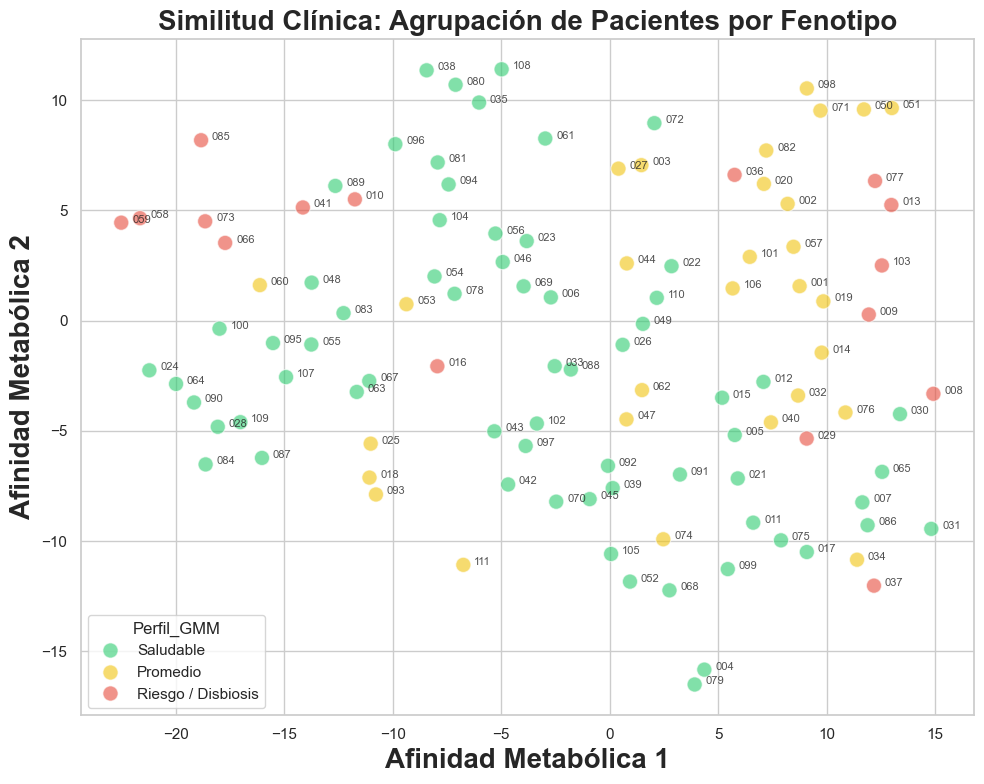

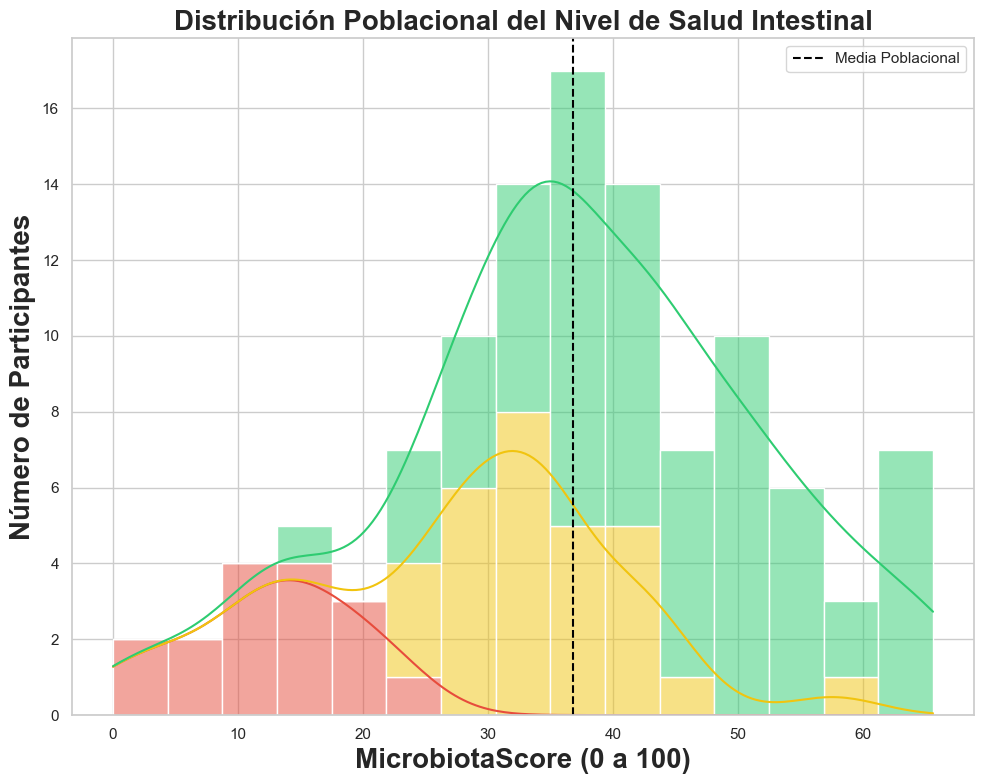

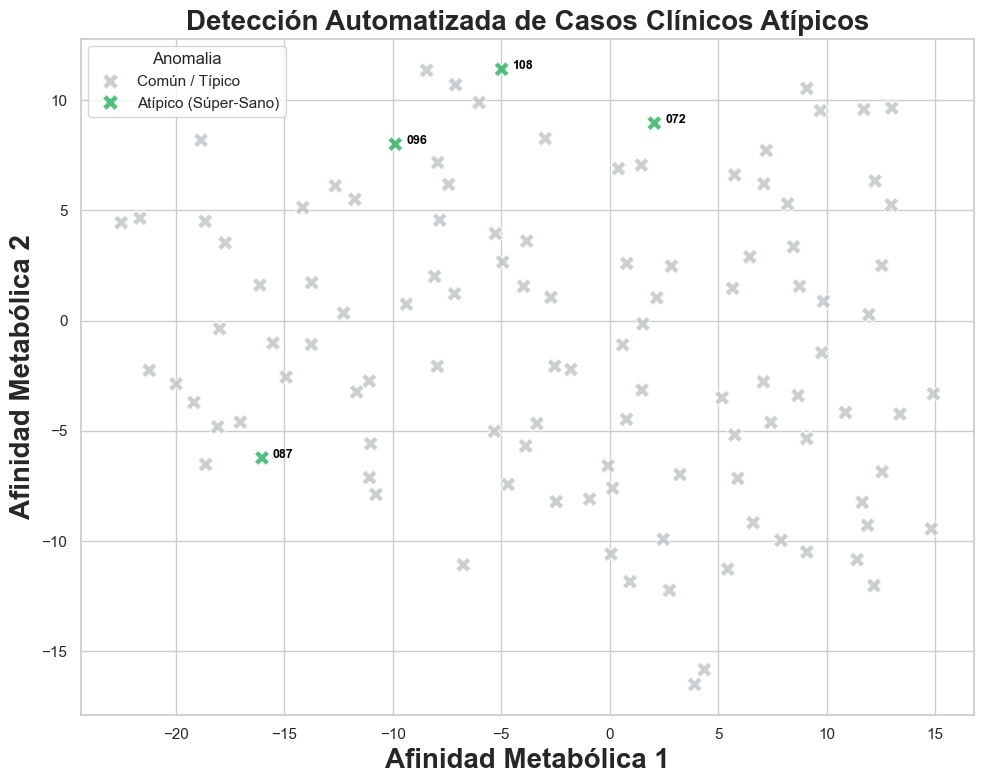


--- REPORTE FINAL DE RESULTADOS COMPLETO ---
    id_match  MicrobiotaScore          Perfil_GMM              Anomalia
49       045        65.606996           Saludable        Común / Típico
20       023        65.563617           Saludable        Común / Típico
91       092        65.466603           Saludable        Común / Típico
70       070        63.354391           Saludable        Común / Típico
81       081        63.151833           Saludable        Común / Típico
69       069        62.447737           Saludable        Común / Típico
44       039        62.050152           Saludable        Común / Típico
43       042        59.160027           Saludable        Común / Típico
57       056        58.486329           Saludable        Común / Típico
47       047        57.636209            Promedio        Común / Típico
31       033        55.264144           Saludable        Común / Típico
105      105        54.474046           Saludable        Común / Típico
86       086      

In [ ]:
from sklearn.manifold import TSNE

# GMM, anomalías y Microbiota Score

# 1. Definición del estado ideal y pesos (Traducción Médico-Matemática)
# Definimos cómo se ve un "paciente perfecto" (el 'ideal') y qué tanto daño 
# hace cada variable si te alejas de ese ideal (el 'peso').
config_clinica = {
    # PESO ALTO (3.0)
    # A estas variables les dimos el impacto máximo porque tienen evidencia contundente de causar disbiosis severa, inflamación sistémica o alterar la permeabilidad intestinal
    'Microbiota_Stress':    {'ideal': 0, 'peso': 3.0},
    # Incluye factores agresivos directos como el uso reciente de antibióticos. Los antibióticos de amplio espectro causan una devastación masiva de las poblaciones bacterianas, reduciendo drásticamente la diversidad alfa, lo cual es el principal indicador de disbiosis aguda.
    'Categoria_Glucosa':    {'ideal': 0, 'peso': 3.0},
    # La resistencia a la insulina y la hiperglucemia alteran la barrera epitelial del intestino y alimentan el sobrecrecimiento de bacterias patógenas, generando un ciclo de inflamación sistémica.
    'Riesgo_cintura':       {'ideal': 0, 'peso': 3.0},
    # La adiposidad central es el principal indicador físico de grasa visceral. La grasa visceral macrófaga libera citocinas proinflamatorias y está directamente correlacionada con la endotoxemia metabólica
    '5.4':                  {'ideal': 0, 'peso': 3.0},  # Enfermedad digestiva
    # Si un paciente ya tiene un diagnóstico clínico (como Síndrome de Intestino Irritable, Colitis o Crohn), la disbiosis ya no es un riesgo, es un hecho patológico. Es la confirmación clínica directa del daño en la microbiota.
    # PESO MEDIO-ALTO (2.5)
    # No son diagnósticos agudos, pero son el combustible diario que determina qué tipo de bacterias sobreviven en el ecosistema intestinal.
    'Diet_Score':           {'ideal': 12, 'peso': 2.5},
    # La dieta es el principal factor maleable de la microbiota. Un score ideal indica alto consumo de fibra prebiótica (que las bacterias fermentan para producir Ácidos Grasos de Cadena Corta como el butirato, esenciales para la salud del colon) y bajo consumo de ultraprocesados.
    'Lifestyle_Score':      {'ideal': 5,  'peso': 2.5},
    # Incluye sueño, actividad física y toxinas (alcohol/tabaco). El intestino tiene su propio ritmo circadiano. La privación de sueño y el tabaquismo alteran la motilidad intestinal y aumentan el estrés oxidativo en la mucosa gástrica.

    # PESO MEDIO (2.0)
    # Son las consecuencias fisiológicas medibles de cómo está funcionando el intestino y el metabolismo general.
    'pH Salival': {'ideal': 7.0, 'peso': 2.0}, # Un pH neutro es ideal.
    'IMC':                  {'ideal': 22, 'peso': 2.0},
    # Un IMC de 22 refleja normopeso. Se le da un peso de 2.0 (menor que a la cintura) porque el IMC no distingue entre masa muscular y masa grasa, por lo que es un indicador metabólico un poco menos preciso que la circunferencia abdominal.
    '4.1 ¿Cuál de las siguientes imágenes representa mejor el tipo de heces que tienes la mayoría de los días?': 
                            {'ideal': 4,  'peso': 2.0},
    # El Bristol 4 (forma de salchicha lisa) es el estándar de oro clínico para un tránsito intestinal óptimo. Tránsitos muy rápidos (diarrea) arrastran bacterias benéficas; tránsitos muy lentos (estreñimiento) promueven la putrefacción de proteínas y la liberación de toxinas (como el amoníaco).
    '4.2':                  {'ideal': 1,  'peso': 2.0}, # Evacuación diaria
    # Evacuar una vez al día asegura que no haya un estancamiento de desechos que altere el pH del colon, lo cual favorecería el crecimiento de patógenos.
    
    # PESO MENOR (1.0 a 1.5)
    # Son variables de contexto que influyen en la microbiota, pero cuyo impacto directo es menor o puede ser compensado por el estilo de vida actual.
    '1.3':                  {'ideal': 0,  'peso': 1.5}, # Nacimiento (0=Vaginal)
    # El nacimiento vaginal proporciona la primera "siembra" de bacterias benéficas (Lactobacillus y Bifidobacterium) de la madre al bebé. Nacer por cesárea retrasa esta colonización
    'Taquicardia_reposo':   {'ideal': 0,  'peso': 1.0},
    # Indicador de un tono simpático elevado (estrés crónico o mala condición cardiovascular). El eje Intestino-Cerebro se comunica vía el nervio vago; un tono simpático alto inhibe la digestión y la motilidad.
    'Temperatura (°C)':     {'ideal': 36.5,'peso': 1.0},
    # Variaciones ligeras pueden indicar la tasa metabólica basal o inflamación de bajo grado, pero es un factor muy general.
    
    # PESO MUY BAJO (0.5)
    'Fitzpatrick Scale':    {'ideal': 3,  'peso': 0.5}
    # Esta escala mide el fototipo de piel. Su única relación con la microbiota es indirecta: los fototipos más oscuros tienen mayor dificultad para sintetizar Vitamina D a partir del sol, y la Vitamina D es un modulador importante de la inmunidad intestinal.
}

# Filtramos las columnas asegurando que existan en el dataframe
cols_score = [col for col in config_clinica.keys() if col in df_final.columns]

# 2. Cálculo de Z-SCORES (Estandarización)
 # Problema: No podemos restar "kilos" menos "latidos por minuto". 
# Solución: Convertimos todo a "Z-Scores" (desviaciones estándar). Así, todas las variables hablan el mismo idioma estadístico antes de calcular distancias.
scaler_z = StandardScaler()
df_raw_score = df_final[cols_score].copy()

# Rellenamos huecos con la mediana poblacional para que el escalador no falle
for col in cols_score:
    df_raw_score[col] = df_raw_score[col].fillna(df_raw_score[col].median())

# Z-scores de los pacientes reales (aquí lo mando a llamar)
Z_pacientes = scaler_z.fit_transform(df_raw_score)
df_Z = pd.DataFrame(Z_pacientes, columns=cols_score, index=df_final.index)

# Z-score del Vector Ideal (usando los parámetros de la población real)
vector_ideal_crudo = [config_clinica[col]['ideal'] for col in cols_score]
vector_ideal_Z = scaler_z.transform([vector_ideal_crudo])[0]

# 3. Distancia biomatemática ponderada (Aprox. Mahalanobis)

distancias = []
pesos = np.array([config_clinica[col]['peso'] for col in cols_score])

for i in range(len(df_Z)):
    paciente_Z = df_Z.iloc[i].values
    # Calculamos qué tan lejos está el paciente del "punto perfecto" en un espacio multidimensional, multiplicando esa distancia por la gravedad médica (peso) de cada variable.
    distancia_cuadrada = np.sum(pesos * (paciente_Z - vector_ideal_Z)**2)
    distancias.append(np.sqrt(distancia_cuadrada))

df_final['Distancia_Ideal'] = distancias
d_max = df_final['Distancia_Ideal'].max() # Buscamos al paciente más enfermo (el más lejano)

# 4. Microbiota Score (Escala Clínica de 0 a 100)
# 100 = Estás exactamente en el punto ideal. 0 = Eres el paciente con mayor riesgo.
df_final['MicrobiotaScore'] = 100 * (1 - (df_final['Distancia_Ideal'] / d_max))
print("MicrobiotaScore calculado exitosamente.")

# 5. Matriz de aprendizaje para GMM

df_modelo = df_Z.copy()
# Multiplicamos el score por 3 para obligar al algoritmo de clustering a darle prioridad al nivel de salud general por encima de variaciones aleatorias.
df_modelo['MicrobiotaScore_Weighted'] = df_final['MicrobiotaScore'] * 3 

# 6. Reducción de dimensionalidad avanzada (t-SNE en lugar de PCA)
# Usamos df_Z (la matriz clínica pura) en lugar de df_modelo.
# Si usamos df_modelo, el "MicrobiotaScore * 3" domina tanto la matemática que t-SNE se vuelve ciego a los síntomas y solo dibuja una línea recta.
# Perplexity=15 es ideal para separar grupos en muestras de ~100 pacientes.

tsne = TSNE(n_components=2, perplexity=15, random_state=42) #(aquí se manda a llamar tsne)
componentes_tsne = tsne.fit_transform(df_Z)

df_final['TSNE_X'] = componentes_tsne[:, 0]
df_final['TSNE_Y'] = componentes_tsne[:, 1]
print("Mapa t-SNE generado exitosamente.")

# 7. GAUSSIAN MIXTURE MODEL (3 grupos)
# Usamos GMM porque asume que las poblaciones biológicas siguen distribuciones normales (campanas).
# Pedimos 3 grupos explícitamente para no forzar una clasificación binaria (Sano vs Enfermo), permitiendo descubrir la "zona gris" metabólica (Promedio).
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42) #(aquí se manda a llamar gmm)
df_final['Cluster_ID'] = gmm.fit_predict(df_modelo)

# Etiquetado Semántico automático basado en el MicrobiotaScore
resumen_clusters = df_final.groupby('Cluster_ID')['MicrobiotaScore'].mean().sort_values(ascending=False)
diccionario_clusters = {
    resumen_clusters.index[0]: 'Saludable',
    resumen_clusters.index[1]: 'Promedio',
    resumen_clusters.index[2]: 'Riesgo / Disbiosis'
}
df_final['Perfil_GMM'] = df_final['Cluster_ID'].map(diccionario_clusters)
print("Clustering GMM (3 grupos) completado.")

# 8. Detección de anomalías (Inteligente por Clúster)
# Este algoritmo busca "outliers" (pacientes cuyas combinaciones de datos son extremadamente raras).
iso_forest = IsolationForest(contamination=0.1, random_state=42)
anomalias_pred = iso_forest.fit_predict(df_modelo)

# No basta con saber que son raros, necesitamos saber su contexto clínico:
condiciones = [
    (anomalias_pred == -1) & (df_final['Perfil_GMM'] == 'Saludable'),           # Verdes con hábitos atípicamente perfectos
    (anomalias_pred == -1) & (df_final['Perfil_GMM'] == 'Riesgo'),  # Rojos con cuadros clínicos extremos
    (anomalias_pred == -1) & (df_final['Perfil_GMM'] == 'Promedio')             # Amarillos con fenotipos incongruentes (ej. comen pésimo pero hacen mucho ejercicio)
]

etiquetas = [
    'Atípico (Súper-Sano)', 
    'Atípico (Disbiosis)',
    'Atípico (Perfil Incongruente)'
]

df_final['Anomalia'] = np.select(condiciones, etiquetas, default='Común / Típico')
print("Detección de Anomalías ajustada a los 3 clústeres.")

# 9. Visualizaciones finales (Gráficas Separadas)

sns.set_theme(style="whitegrid")

# ==============================================================================
# Gráfica A: Mapa de Clústeres (GMM sobre t-SNE)
# ==============================================================================
plt.figure(figsize=(10, 8)) # Abrimos un lienzo nuevo y amplio para esta gráfica

sns.scatterplot(x='TSNE_X', y='TSNE_Y', hue='Perfil_GMM', 
                palette={'Saludable':'#2ecc71', 'Promedio':'#f1c40f', 'Riesgo / Disbiosis':'#e74c3c'},
                data=df_final, s=120, alpha=0.6)

plt.title('Similitud Clínica: Agrupación de Pacientes por Fenotipo', fontsize=20, fontweight='bold')
plt.xlabel('Afinidad Metabólica 1', fontsize=20, fontweight='bold')
plt.ylabel('Afinidad Metabólica 2', fontsize=20, fontweight='bold')

# Imprimimos los IDs de TODOS los pacientes
for i in range(df_final.shape[0]):
    plt.text(df_final['TSNE_X'].iloc[i] + 0.5, df_final['TSNE_Y'].iloc[i], 
             str(df_final['id_match'].iloc[i]), fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show() # <--- Mostramos y cerramos esta gráfica antes de hacer la siguiente


# ==============================================================================
# Gráfica B: Distribución del Microbiota Score
# ==============================================================================
plt.figure(figsize=(10, 8)) # Abrimos otro lienzo nuevo

sns.histplot(data=df_final, x='MicrobiotaScore', hue='Perfil_GMM', multiple="stack", 
             palette={'Saludable':'#2ecc71', 'Promedio':'#f1c40f', 'Riesgo / Disbiosis':'#e74c3c'},
             kde=True, bins=15)

plt.axvline(df_final['MicrobiotaScore'].mean(), color='black', linestyle='--', label='Media Poblacional')

plt.title('Distribución Poblacional del Nivel de Salud Intestinal', fontsize=20, fontweight='bold')
plt.xlabel('MicrobiotaScore (0 a 100)', fontsize=20, fontweight='bold')
plt.ylabel('Número de Participantes', fontsize=20, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show() # <--- Mostramos la segunda gráfica


# ==============================================================================
# Gráfica C: Anomalías Clínicas
# ==============================================================================
plt.figure(figsize=(10, 8)) # Abrimos el último lienzo

sns.scatterplot(x='TSNE_X', y='TSNE_Y', hue='Anomalia', 
                palette={'Común / Típico':'#bdc3c7', 
                         'Atípico (Riesgo/Disbiosis)':'#8e44ad', 
                         'Atípico (Súper-Sano)':'#27ae60',
                         'Atípico (Perfil Incongruente)':'#e67e22'}, 
                data=df_final, s=120, marker='X', alpha=0.8)

plt.title('Detección Automatizada de Casos Clínicos Atípicos', fontsize=20, fontweight='bold')
plt.xlabel('Afinidad Metabólica 1', fontsize=20, fontweight='bold')
plt.ylabel('Afinidad Metabólica 2', fontsize=20, fontweight='bold')

# Ponemos los IDs solo a las anomalías
for i in range(df_final.shape[0]):
    if df_final['Anomalia'].iloc[i] != 'Común / Típico':
        plt.text(df_final['TSNE_X'].iloc[i] + 0.5, df_final['TSNE_Y'].iloc[i], 
                 str(df_final['id_match'].iloc[i]), fontsize=9, color='black', fontweight='bold')

plt.tight_layout()
plt.show() # <--- Mostramos la última gráfica

# 10. Reporte final y exportación

cols_reporte = ['id_match', 'MicrobiotaScore', 'Perfil_GMM', 'Anomalia']
cols_rep_validas = [c for c in cols_reporte if c in df_final.columns]

# Creamos la tabla final ordenada
tabla_resultados = df_final[cols_rep_validas].sort_values('MicrobiotaScore', ascending=False)

print("\n--- REPORTE FINAL DE RESULTADOS COMPLETO ---")
# El .to_string() fuerza a la terminal a mostrar las 113 filas sin usar los "..."
print(tabla_resultados.to_string())

# Guardar datos en excel
tabla_resultados.to_excel('Resultados_MicrobiotaScore.xlsx', index=False)
print("\n¡Listo! Se ha creado el archivo 'Resultados_MicrobiotaScore.xlsx' en tu carpeta.")

# ==============================================================================
# 11. MÓDULO INTERACTIVO DE TAMIZAJE (NUEVO PACIENTE) - VERSIÓN CORREGIDA
# ==============================================================================
import time

print("\n" + "="*75)
print(" SISTEMA DE TAMIZAJE PREVENTIVO - MICROBIOTA SCORE")
print("="*75)
print("Ingrese los datos del paciente (Use los números indicados en las opciones)\n")

try:
    # --- FORMULARIO 1: Antropometría y Clínica ---
    print("--- FASE 1: Antropometría y Clínica ---")
    peso      = float(input("Peso (kg): "))
    estatura  = float(input("Estatura (cm, ej. 165): "))
    cintura   = float(input("Circunferencia de cintura (cm): "))
    sexo      = input("Sexo biológico (M/F): ").strip().upper()
    fc        = int(input("Frecuencia Cardíaca en reposo (BPM): "))
    glucosa   = float(input("Glucosa en Sangre (Mg/dL): "))
    ph_salival= float(input("pH Salival (ej. 7.0): "))
    temp      = float(input("Temperatura corporal basal (grados C): "))
    fitzpatrick = int(input("Escala Fitzpatrick de piel (1=Muy clara a 6=Muy oscura): "))

    print("\n--- FASE 2: Hábitos y Estilo de Vida ---")
    p_1_3  = int(input("Nacimiento por cesarea (0=No/Vaginal, 1=Si/Cesarea): "))
    p_2_1  = int(input("Dias de ejercicio a la semana (0=Nunca, 1=1-2 dias, 2=3-4 dias, 3=5 o mas): "))
    p_2_4  = int(input("Horas sentado al dia (0=Menos de 4, 1=4-6, 2=7-9, 3=Mas de 9): "))
    p_6_7  = int(input("Calidad de sueno (1=Muy mala, 2=Mala, 3=Adecuada, 4=Buena, 5=Excelente): "))
    p_6_2  = int(input("Nivel de estres (1=Bajo, 2=Moderado, 3=Alto, 4=Muy alto): "))
    p_6_3  = int(input("Fumas (0=No, 1=Si): "))
    p_6_5  = int(input("Consumes alcohol (0=No, 1=Si): "))
    p_6_10 = int(input("Uso de enjuague bucal (0=No, 1=Ocasional, 2=Varias/semana, 3=Diario): "))

    print("\n--- FASE 3: Dieta y Digestión ---")
    p_3_1  = int(input("Horas de ayuno diario (0=Menos de 8h, 1=8-10h, 2=10-12h, 3=Mas de 12h): "))
    p_3_8  = int(input("Frecuencia de consumo de fibra (0=Nunca, 1=1-2/sem, 2=3-5/sem, 3=Diario): "))
    p_3_6  = int(input("Consumo de fermentados (0=Nunca, 1=Rara vez, 2=Ocasional, 3=Frecuente): "))
    p_3_5  = int(input("Consumo de ultraprocesados (0=Nunca, 1=1-2/sem, 2=3-4/sem, 3=5 o mas): "))
    p_3_12 = int(input("Consumo de edulcorantes (0=No, 1=Ocasional, 2=Varias/semana, 3=Diario): "))
    p_4_1  = int(input("Escala de Bristol (1=Estrenimiento duro, 4=Ideal, 7=Diarrea liquida): "))
    p_4_2  = int(input("Frecuencia de evacuacion (0=Menos de 3/semana, 1=1 al dia, 2=2-3 al dia, 3=Mas de 3): "))

    print("\n--- FASE 4: Alertas Clínicas ---")
    p_5_4  = int(input("Enfermedad digestiva diagnosticada [Crohn, Colitis, etc.] (0=No, 1=Si): "))
    p_5_1  = int(input("Cuantas veces te enfermas al año (1=1 vez, 2=2-3 veces, 3=4 o mas): "))
    p_5_3  = int(input("Toma de antibioticos en los ultimos 3 meses (0=No, 1=Si): "))
    p_5_7  = int(input("Infeccion gastrointestinal en los ultimos 3 meses (0=No, 1=Si): "))
    p_6_13 = int(input("Problemas digestivos por estres [Inflamacion, diarrea, etc.] (0=Nunca, 1=A veces, 2=Frecuente, 3=Diario): "))

    print("\nDe la siguiente lista de sintomas, cuantos presentas frecuentemente?")
    print("(Acidez, Inflamacion, Gases, Estrenimiento, Diarrea, Dolor abdominal, Nauseas)")
    carga_sintomas = int(input("Ingresa el numero total de sintomas (0 a 7): "))

    print("\nProcesando biomarcadores", end="")
    for _ in range(3):
        time.sleep(0.5)
        print(".", end="", flush=True)

    # ==========================================================================
    # CÁLCULO DE VARIABLES DERIVADAS
    # Usamos exactamente la misma lógica que el modelo original, sin cambiar nada
    # ==========================================================================

    # IMC
    imc_n = peso / (estatura / 100)**2

    # Taquicardia
    taquicardia_n = 1 if fc > 90 else 0

    # Riesgo cintura (mismos criterios IDF que riesgo_cintura() en el modelo)
    if 'mujer' in sexo.lower() or sexo == 'F':
        riesgo_cintura_n = 1 if cintura >= 80 else 0
    elif 'hombre' in sexo.lower() or sexo == 'M':
        riesgo_cintura_n = 1 if cintura >= 94 else 0
    else:
        riesgo_cintura_n = 1 if cintura >= 90 else 0

    # Categoría glucosa (misma lógica que clasificacion_glucosa_ajustada())
    if p_3_1 == 0:  # Postprandial
        if glucosa < 140:             cat_glucosa_n = 0
        elif 140 <= glucosa < 200:    cat_glucosa_n = 1
        else:                         cat_glucosa_n = 2
    else:           # Ayuno
        if glucosa < 100:             cat_glucosa_n = 0
        elif 100 <= glucosa < 126:    cat_glucosa_n = 1
        else:                         cat_glucosa_n = 2

    # Scores (mismas fórmulas exactas del modelo original)
    diet_score_n       = (p_3_8 * 10) + (p_3_6 * 7) - (p_3_5 * 9) - (p_3_12 * 8)
    mal_sueno_n        = 5 - p_6_7
    lifestyle_score_n  = (p_2_1 * 8) - (p_2_4 * 7) - (p_6_2 * 9) - (p_6_3 * 5) - (p_6_5 * 7) - (p_6_10 * 4) - mal_sueno_n
    microbiota_stress_n= (p_5_3 * 10) + (p_5_7 * 9) + (p_5_1 * 4) + (p_6_13 * 5) + (carga_sintomas * 5)

    # ==========================================================================
    # EMPAQUETADO SEGURO: construimos el DataFrame en el orden EXACTO de cols_score
    # Este es el fix principal. No usamos un diccionario desordenado.
    # Mapeamos cada nombre de columna a su valor calculado.
    # ==========================================================================

    # Nombre largo de la columna 4.1 (debe ser idéntico al que quedó en df_final)
    col_bristol = [c for c in df_final.columns if str(c).startswith('4.1')]
    nombre_bristol = col_bristol[0] if col_bristol else '4.1'

    mapa_valores = {
        'Microbiota_Stress' : microbiota_stress_n,
        'Categoria_Glucosa' : cat_glucosa_n,
        'Riesgo_cintura'    : riesgo_cintura_n,
        '5.4'               : p_5_4,
        'Diet_Score'        : diet_score_n,
        'Lifestyle_Score'   : lifestyle_score_n,
        'pH Salival'        : ph_salival,
        'IMC'               : imc_n,
        nombre_bristol      : p_4_1,
        '4.2'               : p_4_2,
        '1.3'               : p_1_3,
        'Taquicardia_reposo': taquicardia_n,
        'Temperatura (°C)'  : temp,
        'Fitzpatrick Scale' : fitzpatrick
    }

    # Construimos una sola fila respetando el orden exacto de cols_score
    fila_ordenada = [mapa_valores[col] for col in cols_score]
    df_nuevo = pd.DataFrame([fila_ordenada], columns=cols_score)

    # ==========================================================================
    # DIAGNÓSTICO AUTOMÁTICO: compara contra el participante real si existe
    # Cambia el ID aquí para verificar contra quien quieras
    # ==========================================================================
    ID_VERIFICACION = input("\n\nIngresa el ID del participante para verificar (ej. 001) o Enter para saltar: ").strip()

    if ID_VERIFICACION and ID_VERIFICACION in df_final['id_match'].values:
        participante_real = df_final[df_final['id_match'] == ID_VERIFICACION][cols_score]
        print(f"\n--- DIAGNÓSTICO: comparando contra participante {ID_VERIFICACION} ---")
        print(f"{'Variable':<55} {'Original':>10} {'Nuevo':>10} {'Dif':>10}")
        print("-" * 90)
        hay_diferencias = False
        for col in cols_score:
            val_orig = participante_real[col].values[0]
            val_nuevo = df_nuevo[col].values[0]
            diferencia = val_nuevo - val_orig
            alerta = " <-- REVISAR" if abs(diferencia) > 0.01 else ""
            if abs(diferencia) > 0.01:
                hay_diferencias = True
            print(f"{str(col):<55} {val_orig:>10.2f} {val_nuevo:>10.2f} {diferencia:>10.2f}{alerta}")
        if not hay_diferencias:
            print("\nTodos los valores coinciden perfectamente.")
        print("-" * 90)
    
    # ==========================================================================
    # PREDICCIÓN CON LOS MODELOS YA ENTRENADOS
    # ==========================================================================

    # 1. Estandarización usando el scaler entrenado con la población
    Z_nuevo = scaler_z.transform(df_nuevo)

    # 2. Distancia al vector ideal (misma fórmula que el modelo)
    distancia_cuadrada_n = np.sum(pesos * (Z_nuevo[0] - vector_ideal_Z)**2)
    distancia_n = np.sqrt(distancia_cuadrada_n)
    score_n = 100 * (1 - (distancia_n / d_max))
    score_n = max(0, min(100, score_n))  # Clamp entre 0 y 100

    # 3. Predicción GMM
    df_modelo_nuevo = pd.DataFrame(Z_nuevo, columns=cols_score)
    df_modelo_nuevo['MicrobiotaScore_Weighted'] = score_n * 3
    cluster_nuevo = gmm.predict(df_modelo_nuevo)[0]
    perfil_nuevo  = diccionario_clusters[cluster_nuevo]

    # 4. Detección de anomalías
    anomalia_nueva = iso_forest.predict(df_modelo_nuevo)[0]
    es_anomalia = "SI (Requiere validacion medica)" if anomalia_nueva == -1 else "No (Paciente en distribucion esperada)"

    # ==========================================================================
    # TABLERO DE RESULTADOS
    # ==========================================================================
    print("\n\n" + "="*75)
    print(" REPORTE DE TAMIZAJE (PACIENTE NUEVO)")
    print("="*75)
    print(f" IMC Calculado              : {imc_n:.1f}")
    print(f" Diet Score                 : {diet_score_n}")
    print(f" Microbiota Stress          : {microbiota_stress_n}")
    print(f" Lifestyle Score            : {lifestyle_score_n}")
    print("-" * 75)
    print(f" MICROBIOTA SCORE FINAL     : {score_n:.1f} / 100")
    print(f" FENOTIPO GMM PREDICHO      : {perfil_nuevo.upper()}")
    print(f" DETECCION DE ANOMALIAS     : {es_anomalia}")
    print("="*75)

    # Si se verificó contra un participante real, mostramos comparación de scores
    if ID_VERIFICACION and ID_VERIFICACION in df_final['id_match'].values:
        score_original = df_final[df_final['id_match'] == ID_VERIFICACION]['MicrobiotaScore'].values[0]
        print(f"\n Score original del participante {ID_VERIFICACION}: {score_original:.1f}")
        print(f" Score recalculado ahora              : {score_n:.1f}")
        print(f" Diferencia                           : {abs(score_n - score_original):.1f} puntos")
        if abs(score_n - score_original) < 1.0:
            print(" El modulo funciona correctamente.")
        else:
            print(" Hay diferencia. Revisa las filas marcadas con <-- REVISAR arriba.")

except ValueError as e:
    print(f"\nError de formato: {e}")
    print("Asegurate de ingresar unicamente numeros cuando se solicite.")
except Exception as e:
    print(f"\nError inesperado: {e}")
    import traceback
    traceback.print_exc()

In [10]:
# ==============================================================================
# GUARDAR EL MODELO ENTRENADO
# ==============================================================================
import joblib

# Empaquetamos todo lo que necesita el módulo 11 en un solo diccionario
modelo_completo = {
    # El scaler entrenado con la población (media y desviación estándar)
    'scaler_z': scaler_z,
    
    # El GMM entrenado (3 clusters)
    'gmm': gmm,
    
    # El IsolationForest entrenado
    'iso_forest': iso_forest,
    
    # El vector ideal ya transformado a Z-scores
    'vector_ideal_Z': vector_ideal_Z,
    
    # Los pesos clínicos de cada variable
    'pesos': pesos,
    
    # La distancia máxima (para normalizar el score de 0 a 100)
    'd_max': d_max,
    
    # El orden exacto de columnas que espera el modelo
    'cols_score': cols_score,
    
    # El diccionario que traduce cluster_id a nombre (Saludable, Promedio, Riesgo)
    'diccionario_clusters': diccionario_clusters,
    
    # El nombre exacto de la columna Bristol (es largo y puede variar)
    'nombre_bristol': [c for c in df_final.columns if str(c).startswith('4.1')][0]
}

joblib.dump(modelo_completo, 'microbiota_modelo.pkl')
print("Modelo guardado exitosamente en 'microbiota_modelo.pkl'")

Modelo guardado exitosamente en 'microbiota_modelo.pkl'
